In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

x:\practice\langGraph\.venv\Lib\site-packages\langgraph\checkpoint\base\__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
load_dotenv()

True

In [3]:
model = ChatGoogleGenerativeAI(model="gemini-3.6-flash")

In [ ]:
def call_model(state: MessagesState):  # List[AnyMessage],add_message - system,ai,tool,human....
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [5]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

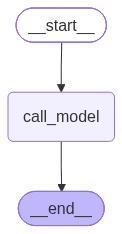

In [6]:
graph = builder.compile()
graph

In [7]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Khan."}]})

{'messages': [HumanMessage(content='Hi! My name is Khan.', additional_kwargs={}, response_metadata={}, id='b549f16e-8492-4f2a-ae79-6e5b6708b450'),
  AIMessage(content=[{'type': 'text', 'text': "Hello Khan! It's very nice to meet you. How can I help you today?", 'extras': {'signature': 'EvYKCvMKARFNMg93pV0gPWeoF3xohjttqhVQxdqv3/lesjogp6Crz1ItAiG7A8rZ4vGFJLv1ib4yVtaeftFiLCjv1jdCDKwRbs+rE2EApD/XSmJ5F+RQEj1pWoSlyqpF7XuDs254mWRJkY2cJ8eSBq1V67hGJ/5NIGLK3jS7qBBilP0ybj2Qfkhtivn26a9p1EYbZhd+N4whfxCJXcyhpGRChpzuLOS0o0lA4sTq/rDJph8SfhzPXmkaZb8xb/tPRKgHyZJdZu3+l1rE7O4XF1huUCM3ncSt6qI1S3KvgLjEsRtzVA3BNsikPv5UqwZkJ5In575/YkL06BaDMxh+rer7J1jrjJHxtsEVHMFuWmeYBVWHOPUIEr/Z2TDn26D6e3rJ0ehC3Iq6bCI1U456/jq6VNMCgCTqSdOSEMh4MNgb0TJwkm7ytyijb97WH/R6zy2M06g9SkdPOF9IWskO21ovnOIQY9UGxhdE5IaUNoFCa7+lQ7tEI0XkdJLVPkj6Yn6SzJXKPuuzBHIdLYEOMMta26YB6iv119ABxABcnHctBi/OFPJqrH3RP69QiRhGGiUnu+c9VsW/VNiValOwcHWQgKO8qXCtb9F0/C5XhY33VQk1cqO8/D/Qr75HixuFMoEp9Dfbktj9JAWZC+dAEFrOGlbHJkOBt2bHouMkCQdAAcLDnwGDbxfXJ37cdqovH7C+iNQ8q

In [8]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]})

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='a43e0eda-9287-4cde-9d29-d85a2ccc5f2a'),
  AIMessage(content=[{'type': 'text', 'text': "I don't know your name because I don't have access to your personal information. What should I call you?", 'extras': {'signature': 'Eu4GCusGARFNMg+JQhsvTP+3ej54ZwiKN6A1RzYB4z8s+dcsFG10B4+Lp8Rr+AZewPAuqkIHhVTWPg49QK4EVlZOQrp/2+9t85hz5HZotr0bOyx1zJUxOVsEFxgC0gj7pR0u1e+PYxo8AYEjIEuMR2qbLhc5vQZ1g691XN1ypPWcTvESxCsztru5h6mZp/nz0lmtQbHedDrm0VVHPw3DHmMdusstjvGK5R4uUbFzoJYE+65fqFgd1OqvuUf3rjhcGZlCvTuEps+56WVraAp6+mq7ZXFP1+xh0TxrJG1nenPm7oZkNZs1q63D9hxZoqVw0txcdWgOyxRcmIzV++lsYOTQLMPn5wMa5LzBcplVw0CWP2YNSrYlaK/imRPwU0hzADGcreGC5EjBYkhFbZxdkjSC5/iUkVip+s7nl2CTka7Frk8MAP8bMwcl/QKyAKVrXdtX/6oKlmB0lOHr6b3ZCE5pIfThnTeW3gcEdwRRyKM1XTJiwmOYB8pcF5B8qqYxXCnbE8Scm8n2xlaWRJPjCKrJRXZCnDiAM4rSp9Cfyx+u/ajQ3zXE1aAQs7ylP/TXpX9E2OG3JyEf3+j3boadQYqWsUEwJfFjiEDZPzjyRUy72JbmYtGq0eVymMcWBwf9V1lw9Agf3ZRaAcKdggCHKGCh63w+6icPY6nyyU

In [9]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [10]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [11]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [12]:
config = {"configurable": {"thread_id": "thread-1"}}
config2 = {"configurable": {"thread_id": "thread-2"}}

In [13]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Khan."}]}, config)

{'messages': [HumanMessage(content='Hi! My name is Khan.', additional_kwargs={}, response_metadata={}, id='607bbd5b-925e-4260-9d30-8f7016eb58fe'),
  AIMessage(content=[{'type': 'text', 'text': "Hello, Khan! It's nice to meet you. How can I help you today?", 'extras': {'signature': 'Ep4LCpsLARFNMg+gIm8hyD+t2NgiKc+/lj5JwzhfdzsRVDkwxMaGvOMsgkKfju3+FxipRSuYF2KFFbs4D3mjU3JI4VFDSCvxayx7pF+OHTBPn64KCgNr5g2b2SPJ2bYKicYxgqpcQPVdDYIL5/H+FxFrbr0Iu9WhOxDdEMQZ4kqDBuVWuwMbhIi+bPg4pLzSeQ+gZ9YFywvU5cSWzgB8hmvLvMtgiZCfR0scdYmfQZsiKpgZQacq7rf9yeI3niqXWkds5NbHiUt/ax33BQ3hJ1AzfyxJITPtc8msnkOU0Zc05ptmEukCwSU2y8rxAXQ9zbJPOEZxySdAPKl81EEb/nG+JEvdQh62SrGMwEaT+KUgDGSxy95hLbLvA4SW1CyAcgGGPnukXnKidQN1+EfjbLLLxyJhGgH63DnAk1G/ZS434v6b04ZpQx8TvjlFK+KZP1vhdxUNCOK31uD3yENSMVSaMzVAX7uwoWjI0DhNbkSuxWjkKcWmQz99QT7+vgzx/yoR82WJGJQNtmkESoF9+1unV3pefuDswpsilGDgOsHMgKXv82t/YYgvsGL+HlcyzzTwpESh70VZ3M7EIh0H/Pv1P4Pc1Fi/AMcjM+YLIsEtbENSLDWwIVnSZ6rb2Hbt8tF87PVdArYK3OMAP8NLR1FO5xdxrNWqgKaxW5lPEsU4WZcOFO2KfB1RT8Rt6jPdcBeL3tJEouIhl

In [15]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]}, config)

{'messages': [HumanMessage(content='Hi! My name is Khan.', additional_kwargs={}, response_metadata={}, id='607bbd5b-925e-4260-9d30-8f7016eb58fe'),
  AIMessage(content=[{'type': 'text', 'text': "Hello, Khan! It's nice to meet you. How can I help you today?", 'extras': {'signature': 'Ep4LCpsLARFNMg+gIm8hyD+t2NgiKc+/lj5JwzhfdzsRVDkwxMaGvOMsgkKfju3+FxipRSuYF2KFFbs4D3mjU3JI4VFDSCvxayx7pF+OHTBPn64KCgNr5g2b2SPJ2bYKicYxgqpcQPVdDYIL5/H+FxFrbr0Iu9WhOxDdEMQZ4kqDBuVWuwMbhIi+bPg4pLzSeQ+gZ9YFywvU5cSWzgB8hmvLvMtgiZCfR0scdYmfQZsiKpgZQacq7rf9yeI3niqXWkds5NbHiUt/ax33BQ3hJ1AzfyxJITPtc8msnkOU0Zc05ptmEukCwSU2y8rxAXQ9zbJPOEZxySdAPKl81EEb/nG+JEvdQh62SrGMwEaT+KUgDGSxy95hLbLvA4SW1CyAcgGGPnukXnKidQN1+EfjbLLLxyJhGgH63DnAk1G/ZS434v6b04ZpQx8TvjlFK+KZP1vhdxUNCOK31uD3yENSMVSaMzVAX7uwoWjI0DhNbkSuxWjkKcWmQz99QT7+vgzx/yoR82WJGJQNtmkESoF9+1unV3pefuDswpsilGDgOsHMgKXv82t/YYgvsGL+HlcyzzTwpESh70VZ3M7EIh0H/Pv1P4Pc1Fi/AMcjM+YLIsEtbENSLDWwIVnSZ6rb2Hbt8tF87PVdArYK3OMAP8NLR1FO5xdxrNWqgKaxW5lPEsU4WZcOFO2KfB1RT8Rt6jPdcBeL3tJEouIhl

In [16]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]}, config2)

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='111bfb21-246a-4fbd-a676-79faa4ffa9b5'),
  AIMessage(content=[{'type': 'text', 'text': "I don't know your name yet! What is it?", 'extras': {'signature': 'EuUECuIEARFNMg/7KwOjIthHq25BJq0lYInBpvQxW9vhanSAAS61hBAYdwmz5eaR2QG85e1xw8crKaDwXYVfn0eC7viZZ9pAyP/yGmilAySaaCzRPTL2XGvMOXHoiY8qdHmdFD2MVlv3L1n3AR2BUTAxYUyvxJZCz2+l4o1nm0Hhi4YZx4YPghRnQFVGK/XRNC+sOBVgyqGpo4oUruTgipwEPW5vuFmf8Np1G/nuPWxurwd/SUCJlEpqaDvKKCtXteZW0OwLEb8vwxutxcl3oXL27kyIfVNs5VLmaaM3ZpplM/yEhVfLjQJyT+/NNPOSntxexYifU/ojcntUoGJOH6g6dXIPYGG71q2EK47rXIxTPo0Fb1N5mxIBQlJ1ToJHNyVEXC1ZnGg47TdfH9/rXAmR0rJrboq+tnB8szeejXW0t6Fjv9tUkcNGvbAvZovq5u1+6pe1RjGGR8JACVD0d0IozT9bcwfvWNjsXNZffizqmsf/qYG08voMavxmktjp1CCJOUg7TbMZiR0R2en1SafpPZl6iJAcTIOJCqIvhdmcIF+qLl7NHDHX5lBGwjQnucpRwRwVZYMzqbAP7bdGAnnGRjWfmtqQWdSRgHM2BzPZa9bDcBDzHzuf/Er45H27hMKuBWRFpmtDoyEI+OjX+BsNEMHpr/KNkegYy5x+HiBsYl5WenhOANVSZ1YXZq1O8N4nUqeR8OdtX9JsQ7wkMhYkqt+c7EczdCLatx5

In [26]:
snap = graph.get_state(config)
vals = snap.values
for m in vals.get("messages", []):
        tpm=type(m).__name__
        if(tpm=="AIMessage"):
                print("-",tpm,m.text)
                continue
        print("-", tpm, ":", m.content)

- HumanMessage : Hi! My name is Khan.
- AIMessage Hello, Khan! It's nice to meet you. How can I help you today?
- HumanMessage : What is my name?
- AIMessage Your name is Khan!
